In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [4]:
df = pd.read_csv("flight.csv")
df


,DayOfWeek,Origin_Airport,Scheduled_Departure,Departure_Time,Dep_Delay,Scheduled_Arrival,Arrival_Time,Arrival_Delay,Arr_Del_morethan15,Cancelled,Diverted,Distance,Carrier_Delay,WeatherDelay,NAS_Delay,Security_Delay,Late_Aircraft_Delay,Top_Carriers
0,5,BOS,600,554,-6,711,707,-4,0,0,0,187,0,0,0,0,0,1
1,6,BOS,600,554,-6,711,703,-8,0,0,0,187,0,0,0,0,0,1
2,1,BOS,600,601,1,711,706,-5,0,0,0,187,0,0,0,0,0,1
3,2,BOS,600,556,-4,711,709,-2,0,0,0,187,0,0,0,0,0,1
4,3,BOS,600,552,-8,711,659,-12,0,0,0,187,0,0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4816,4,LAX,815,845,30,1652,1728,36,1,0,0,2611,30,0,6,0,0,1
4817,5,LAX,815,811,-4,1652,1626,-26,0,0,0,2611,0,0,0,0,0,1
4818,7,LAX,815,809,-6,1652,1619,-33,0,0,0,2611,0,0,0,0,0,1
4819,1,LAX,815,811,-4,1652,1709,17,1,0,0,2611,0,0,17,0,0,1


In [6]:
df.head()

,DayOfWeek,Origin_Airport,Scheduled_Departure,Departure_Time,Dep_Delay,Scheduled_Arrival,Arrival_Time,Arrival_Delay,Arr_Del_morethan15,Cancelled,Diverted,Distance,Carrier_Delay,WeatherDelay,NAS_Delay,Security_Delay,Late_Aircraft_Delay,Top_Carriers
0,5,BOS,600,554,-6,711,707,-4,0,0,0,187,0,0,0,0,0,1
1,6,BOS,600,554,-6,711,703,-8,0,0,0,187,0,0,0,0,0,1
2,1,BOS,600,601,1,711,706,-5,0,0,0,187,0,0,0,0,0,1
3,2,BOS,600,556,-4,711,709,-2,0,0,0,187,0,0,0,0,0,1
4,3,BOS,600,552,-8,711,659,-12,0,0,0,187,0,0,0,0,0,1


# 📚 Literature Review

| Category                     | Source                     | Key Findings                                                                | Method Used                  | Data Issues Noted                     |
| ---------------------------- | -------------------------- | --------------------------------------------------------------------------- | ---------------------------- | ------------------------------------- |
| Flight Delay Distribution    | Aviation Delay Dataset     | Most flights experience small delays, while few show extremely high delays. | Histogram Analysis           | Positively skewed delay values        |
| Departure vs Arrival Delay   | Flight Operational Records | Flights departing late generally arrive late as well.                       | Scatter Plot Analysis        | Presence of outliers                  |
| Weather Delay Analysis       | Weather & Flight Reports   | Weather conditions significantly affect flight schedules.                   | EDA & Visualization          | Missing and zero delay values         |
| Delay Correlation Study      | Flight Delay Dataset       | Departure delay and arrival delay show positive correlation.                | Heatmap Correlation Analysis | Weak correlation among some variables |
| Airport Performance Analysis | Airport Traffic Dataset    | Certain airports experience higher delay frequencies.                       | Count Plot Analysis          | Imbalanced airport records            |


# Hypothesis:-



---



### **Departure Delay has a Direct Impact on Arrival Delay**

Flights that experience higher departure delays are more likely to arrive late at their destination. A positive relationship is expected between departure delay and arrival delay.

---



### **Weather Conditions Significantly Affect Flight Delays**

Weather-related factors such as storms, rainfall, fog, and poor visibility contribute significantly to overall flight delays and operational disruptions.

---



### **Certain Airports Experience Higher Delay Frequency**

Some airports handle a larger number of delayed flights compared to others due to traffic congestion, operational load, or airport management conditions.

---


# Dataset Information:-

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4821 entries, 0 to 4820
Data columns (total 18 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   DayOfWeek            4821 non-null   int64 
 1   Origin_Airport       4821 non-null   object
 2   Scheduled_Departure  4821 non-null   int64 
 3   Departure_Time       4821 non-null   int64 
 4   Dep_Delay            4821 non-null   int64 
 5   Scheduled_Arrival    4821 non-null   int64 
 6   Arrival_Time         4821 non-null   int64 
 7   Arrival_Delay        4821 non-null   int64 
 8   Arr_Del_morethan15   4821 non-null   int64 
 9   Cancelled            4821 non-null   int64 
 10  Diverted             4821 non-null   int64 
 11  Distance             4821 non-null   int64 
 12  Carrier_Delay        4821 non-null   int64 
 13  WeatherDelay         4821 non-null   int64 
 14  NAS_Delay            4821 non-null   int64 
 15  Security_Delay       4821 non-null   int64 
 16  Late_A

# Handled Missing Value:-

In [8]:
df.isnull().sum()

DayOfWeek              0
Origin_Airport         0
Scheduled_Departure    0
Departure_Time         0
Dep_Delay              0
Scheduled_Arrival      0
Arrival_Time           0
Arrival_Delay          0
Arr_Del_morethan15     0
Cancelled              0
Diverted               0
Distance               0
Carrier_Delay          0
WeatherDelay           0
NAS_Delay              0
Security_Delay         0
Late_Aircraft_Delay    0
Top_Carriers           0
dtype: int64

* The dataset contains **no missing values** in any column.

* All features have **complete records**, indicating good data quality and consistency.

* Since no null values are present, the dataset is ready for further **Exploratory Data Analysis (EDA)**.


# Statistics Summary:-

In [9]:
df.describe()

,DayOfWeek,Scheduled_Departure,Departure_Time,Dep_Delay,Scheduled_Arrival,Arrival_Time,Arrival_Delay,Arr_Del_morethan15,Cancelled,Diverted,Distance,Carrier_Delay,WeatherDelay,NAS_Delay,Security_Delay,Late_Aircraft_Delay,Top_Carriers
count,4821.000000,4821.000000,4821.000000,4821.000000,4821.000000,4821.000000,4821.000000,4821.000000,4821.0,4821.0,4821.000000,4821.000000,4821.000000,4821.000000,4821.000000,4821.000000,4821.0
mean,4.153703,1338.688032,1335.738021,22.082141,1502.412777,1468.282099,19.459863,0.322132,0.0,0.0,1549.053516,7.505497,1.382493,6.816013,0.051442,8.968056,1.0
std,2.007099,495.435065,524.024009,68.816913,562.241023,600.535851,71.904659,0.467342,0.0,0.0,914.825705,42.419294,19.499934,24.960025,1.524846,39.956099,0.0
min,1.000000,40.000000,1.000000,-20.000000,5.000000,1.000000,-58.000000,0.000000,0.0,0.0,187.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.0
25%,2.000000,900.000000,857.000000,-4.000000,1131.000000,1053.000000,-11.000000,0.000000,0.0,0.0,740.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.0
50%,4.000000,1335.000000,1334.000000,0.000000,1549.000000,1538.000000,0.000000,0.000000,0.0,0.0,1438.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.0
75%,6.000000,1725.000000,1751.000000,20.000000,1937.000000,1943.000000,25.000000,1.000000,0.0,0.0,2475.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.0
max,7.000000,2357.000000,2400.000000,1333.000000,2359.000000,2400.000000,1355.000000,1.000000,0.0,0.0,3784.000000,1189.000000,1010.000000,359.000000,68.000000,1333.000000,1.0


* The dataset contains **4,821 flight records** with multiple operational and delay-related features.

* The average **Departure Delay** is approximately **22 minutes**, while the average **Arrival Delay** is around **19 minutes**.

* Most flights experience small or moderate delays, as indicated by the median delay values close to zero.

* Some flights show extremely high delay values, indicating the presence of significant outliers in the dataset.

* The average flight distance is approximately **1549 miles**, with distances ranging from short to long-haul flights.




In [10]:
df.duplicated().sum()

np.int64(8)

* The dataset initially contained **8 duplicate records**.

* Duplicate values were successfully identified and removed using the `drop_duplicates()` function.

* Removing duplicate records improved dataset consistency and analysis reliability.

* After preprocessing, the dataset became free from duplicate entries.


In [11]:
df = df.drop_duplicates()

In [12]:
df.duplicated().sum()

np.int64(0)

# Univariate Analysis:-

# Important Features Selected

Departure Delay (Dep_Delay)

Arrival Delay (Arrival_Delay)

Distance (Distance)

Weather Delay (WeatherDelay)

Carrier Delay (Carrier_Delay)

Origin Airport (Origin_Airport)

# Departure Delay Analysis:-

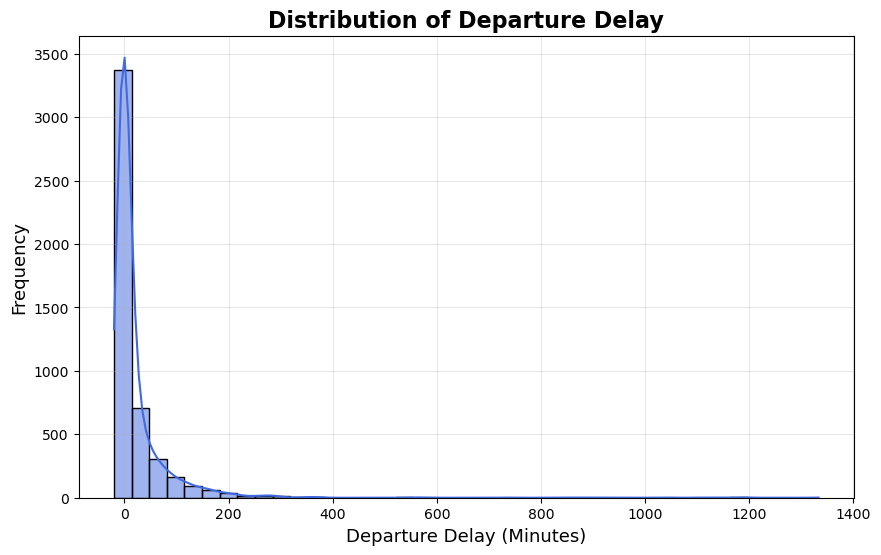

In [15]:

import matplotlib.pyplot as plt
import seaborn as sns

# Figure Size
plt.figure(figsize=(10,6))

# Histogram Plot
sns.histplot(
    data=df,
    x='Dep_Delay',
    bins=40,
    kde=True,
    color='royalblue'
)

# Title and Labels
plt.title('Distribution of Departure Delay',
          fontsize=16,
          fontweight='bold')

plt.xlabel('Departure Delay (Minutes)', fontsize=13)
plt.ylabel('Frequency', fontsize=13)

# Grid
plt.grid(alpha=0.3)

# Show Plot
plt.show()



# Arrival Delay Analysis:-

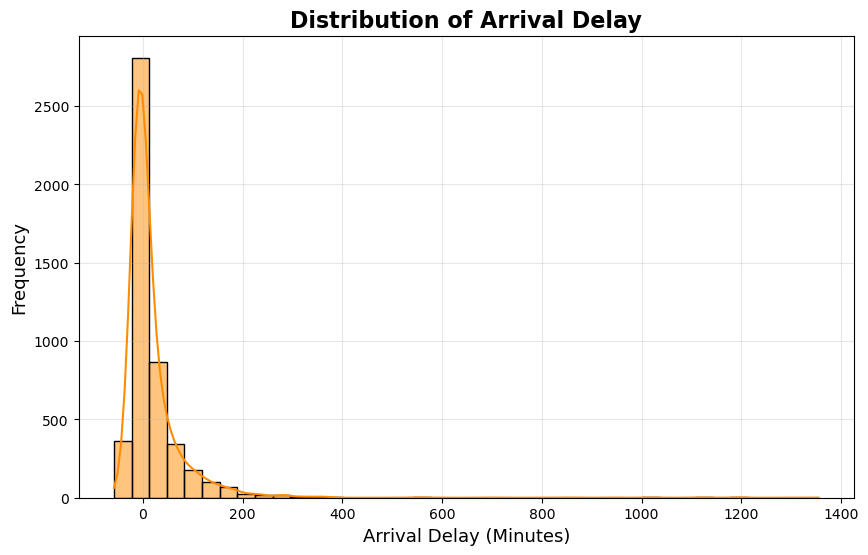

In [16]:

import matplotlib.pyplot as plt
import seaborn as sns

# Figure Size
plt.figure(figsize=(10,6))

# Histogram Plot
sns.histplot(
    data=df,
    x='Arrival_Delay',
    bins=40,
    kde=True,
    color='darkorange'
)

# Title and Labels
plt.title('Distribution of Arrival Delay',
          fontsize=16,
          fontweight='bold')

plt.xlabel('Arrival Delay (Minutes)', fontsize=13)
plt.ylabel('Frequency', fontsize=13)

# Grid
plt.grid(alpha=0.3)

# Show Plot
plt.show()



* Most flights experience **low or moderate arrival delays**.

* A few flights show **extremely high arrival delays**, indicating the presence of outliers.

* The distribution is **positively skewed**, meaning a smaller number of flights face very large delays.

* A large concentration of flights is visible around **zero or small delay values**.

* The graph suggests that many flights arrive close to their scheduled arrival time, while only a limited number experience severe delays.


# Distance Analysis:-

C:\Users\Umesh Chandra\AppData\Local\Temp\ipykernel_25584\1782171367.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Distance'] = pd.to_numeric(df['Distance'], errors='coerce')


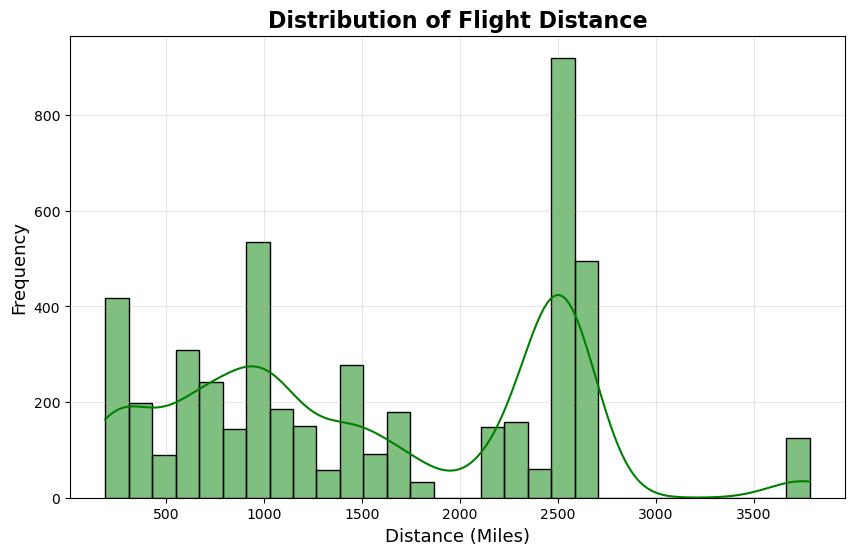

In [17]:

import matplotlib.pyplot as plt
import seaborn as sns

# Convert Distance column to numeric
df['Distance'] = pd.to_numeric(df['Distance'], errors='coerce')

# Figure Size
plt.figure(figsize=(10,6))

# Distance Distribution Plot
sns.histplot(
    df['Distance'],
    bins=30,
    kde=True,
    color='green'
)

# Title and Labels
plt.title('Distribution of Flight Distance',
          fontsize=16,
          fontweight='bold')

plt.xlabel('Distance (Miles)', fontsize=13)
plt.ylabel('Frequency', fontsize=13)

# Grid
plt.grid(True, alpha=0.3)

# Show Plot
plt.show()



# Insight:

The graph represents the distribution of flight distances.

Most flights cover short to medium distances, while only a few flights operate over very long distances.

This creates a right-skewed distribution, indicating that long-distance flights are less frequent compared to shorter routes.

# Weather Delay Analysis:-

C:\Users\Umesh Chandra\AppData\Local\Temp\ipykernel_25584\215690312.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['WeatherDelay'] = pd.to_numeric(df['WeatherDelay'], errors='coerce')


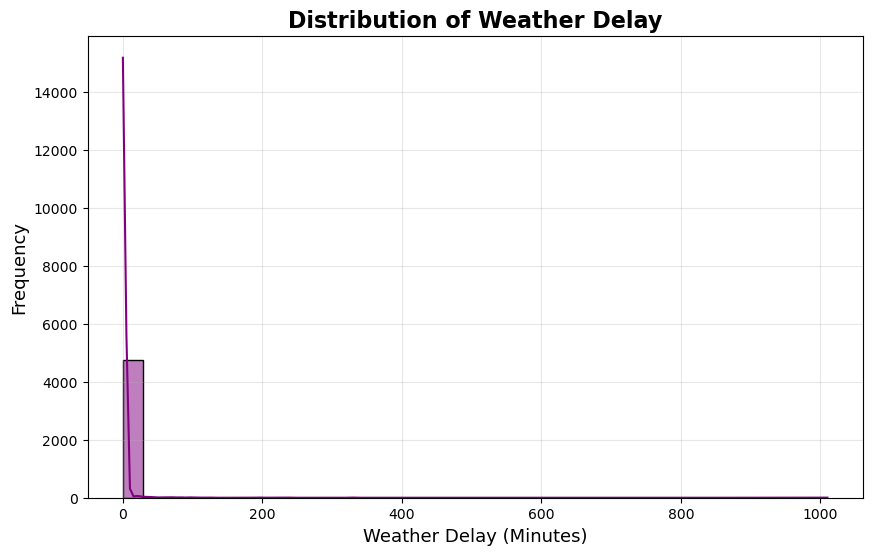

In [18]:

import matplotlib.pyplot as plt
import seaborn as sns

# Convert WeatherDelay column to numeric
df['WeatherDelay'] = pd.to_numeric(df['WeatherDelay'], errors='coerce')

# Figure Size
plt.figure(figsize=(10,6))

# Histogram Plot
sns.histplot(
    data=df,
    x='WeatherDelay',
    bins=35,
    kde=True,
    color='purple'
)

# Title and Labels
plt.title('Distribution of Weather Delay',
          fontsize=16,
          fontweight='bold')

plt.xlabel('Weather Delay (Minutes)', fontsize=13)
plt.ylabel('Frequency', fontsize=13)

# Grid
plt.grid(alpha=0.3)

# Show Plot
plt.show()



* Most flights experience **little or no weather delay**.

* A small number of flights show **extremely high weather-related delays**.

* The distribution is highly **positively skewed** due to a few severe weather cases.

* Weather disruptions affect only a limited number of flights but can create significant operational delays.

* The graph indicates that weather is an occasional but impactful factor in flight scheduling.


# Carrier delay Analysis:-

C:\Users\Umesh Chandra\AppData\Local\Temp\ipykernel_25584\87507245.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Carrier_Delay'] = pd.to_numeric(df['Carrier_Delay'], errors='coerce')


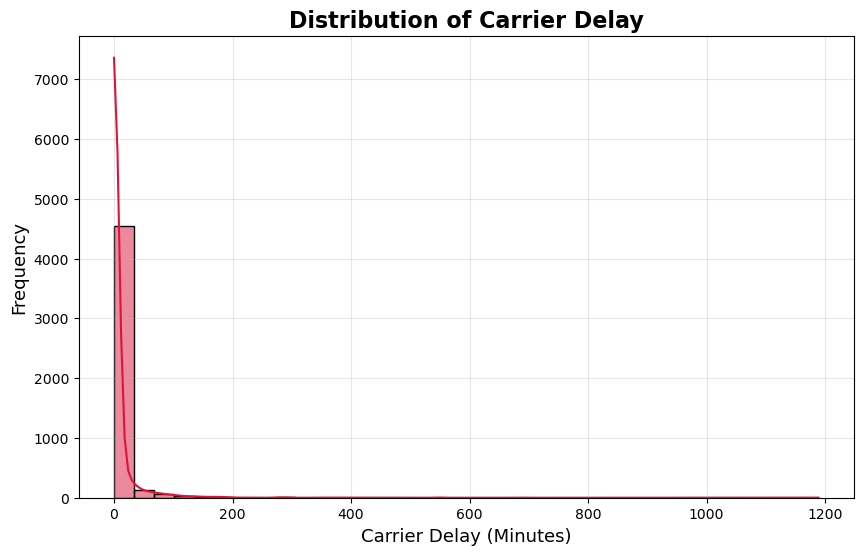

In [19]:

import matplotlib.pyplot as plt
import seaborn as sns

# Convert Carrier_Delay column to numeric
df['Carrier_Delay'] = pd.to_numeric(df['Carrier_Delay'], errors='coerce')

# Figure Size
plt.figure(figsize=(10,6))

# Histogram Plot
sns.histplot(
    data=df,
    x='Carrier_Delay',
    bins=35,
    kde=True,
    color='crimson'
)

# Title and Labels
plt.title('Distribution of Carrier Delay',
          fontsize=16,
          fontweight='bold')

plt.xlabel('Carrier Delay (Minutes)', fontsize=13)
plt.ylabel('Frequency', fontsize=13)

# Grid
plt.grid(alpha=0.3)

# Show Plot
plt.show()



* Most flights show **little or no carrier delay**.

* A small number of flights experience **very high carrier-related delays**, indicating operational issues.

* The distribution is highly **positively skewed** due to extreme delay values.

* Several outliers are present, representing flights with severe carrier disruptions.

* The graph suggests that carrier-related problems affect only a limited number of flights but can significantly impact flight schedules.


# Origin_Airport Analysis:-

C:\Users\Umesh Chandra\AppData\Local\Temp\ipykernel_25584\3333915357.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


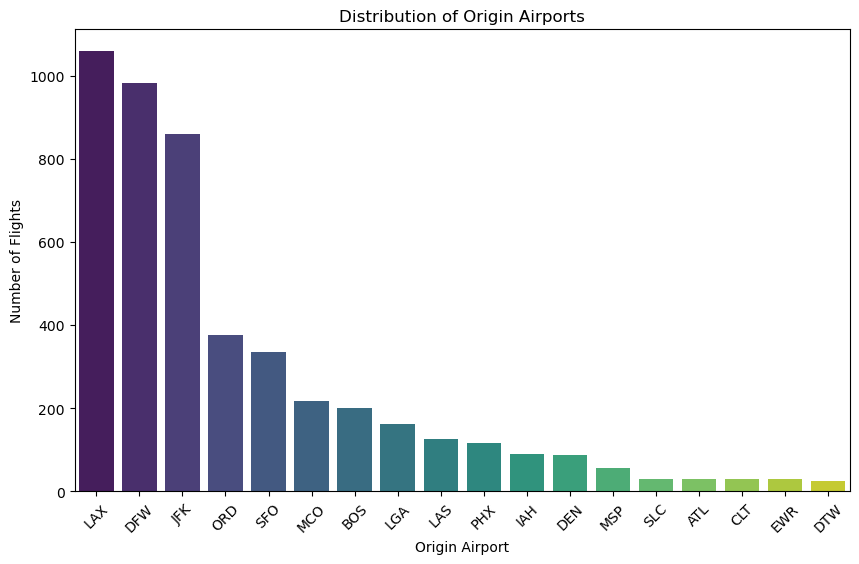

In [24]:
# Origin Airport Distribution

plt.figure(figsize=(10,6))

sns.countplot(
    data=df,
    x='Origin_Airport',
    order=df['Origin_Airport'].value_counts().index,
    palette='viridis'
)

plt.title('Distribution of Origin Airports')
plt.xlabel('Origin Airport')
plt.ylabel('Number of Flights')

plt.xticks(rotation=45)

plt.show()

The graph represents the distribution of flights across different origin airports.

Some airports have a significantly higher number of flights compared to others, indicating that they serve as major air travel hubs.
    
A few airports contribute a smaller number of flights, showing an uneven distribution of flight operations among airports.

# Bivariate Analysis:-

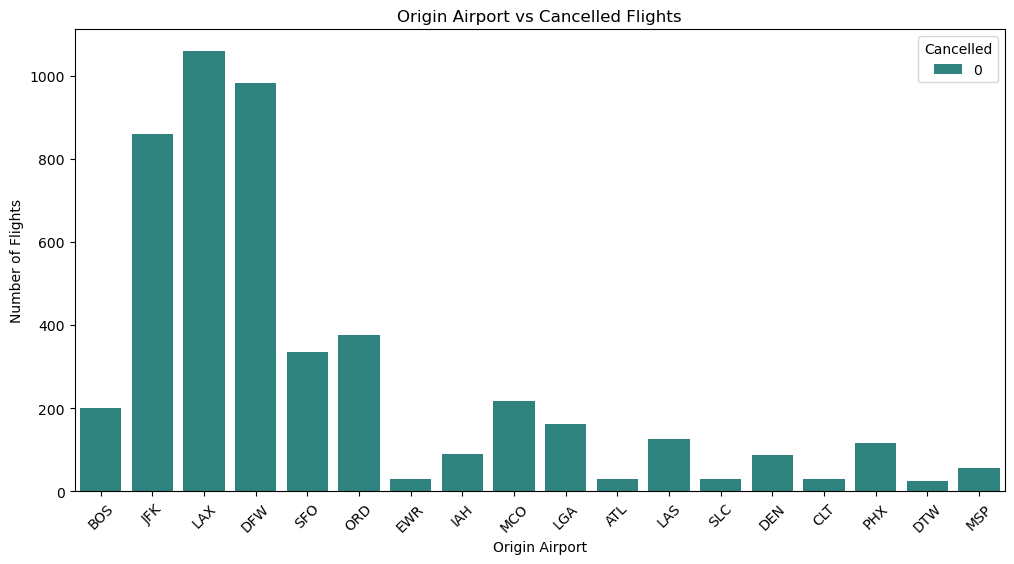

In [27]:
plt.figure(figsize=(12,6))

sns.countplot(
    data=df,
    x='Origin_Airport',
    hue='Cancelled',
    palette='viridis'
)

plt.title('Origin Airport vs Cancelled Flights')
plt.xlabel('Origin Airport')
plt.ylabel('Number of Flights')

plt.xticks(rotation=45)

plt.show()

The graph shows the relationship between origin airports and cancelled flights.

Some airports have a higher number of cancelled flights compared to others, which may indicate operational issues,

weather impact, or heavy air traffic at those airports.

C:\Users\Umesh Chandra\AppData\Local\Temp\ipykernel_25584\3048808877.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


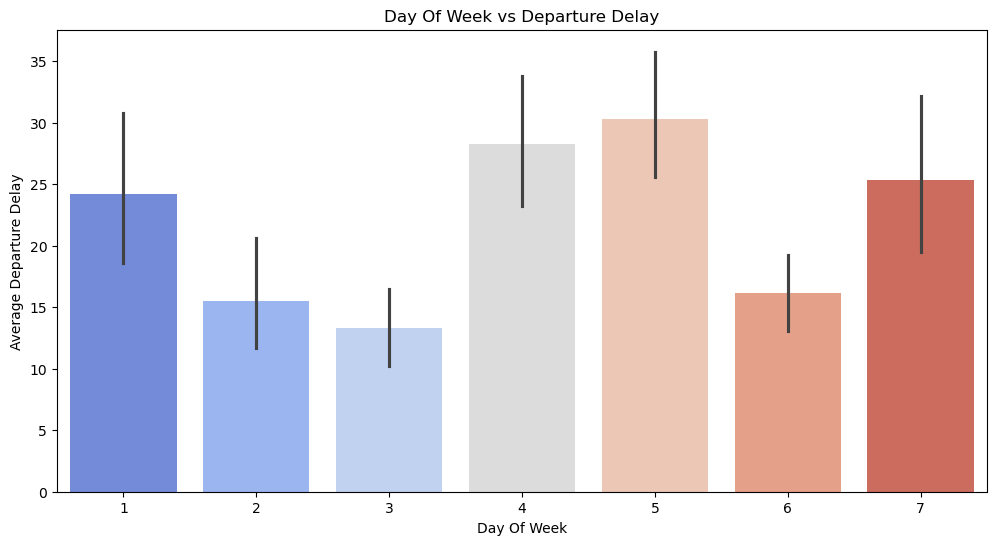

In [28]:
plt.figure(figsize=(12,6))

sns.barplot(
    data=df,
    x='DayOfWeek',
    y='Dep_Delay',
    palette='coolwarm'
)

plt.title('Day Of Week vs Departure Delay')
plt.xlabel('Day Of Week')
plt.ylabel('Average Departure Delay')

plt.show()

The graph represents the average departure delay across different days of the week.

Certain days experience higher delays than others, suggesting that flight congestion and operational load vary throughout the week.

# Top Carriers vs Arrival Delay

C:\Users\Umesh Chandra\AppData\Local\Temp\ipykernel_25584\2960149428.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


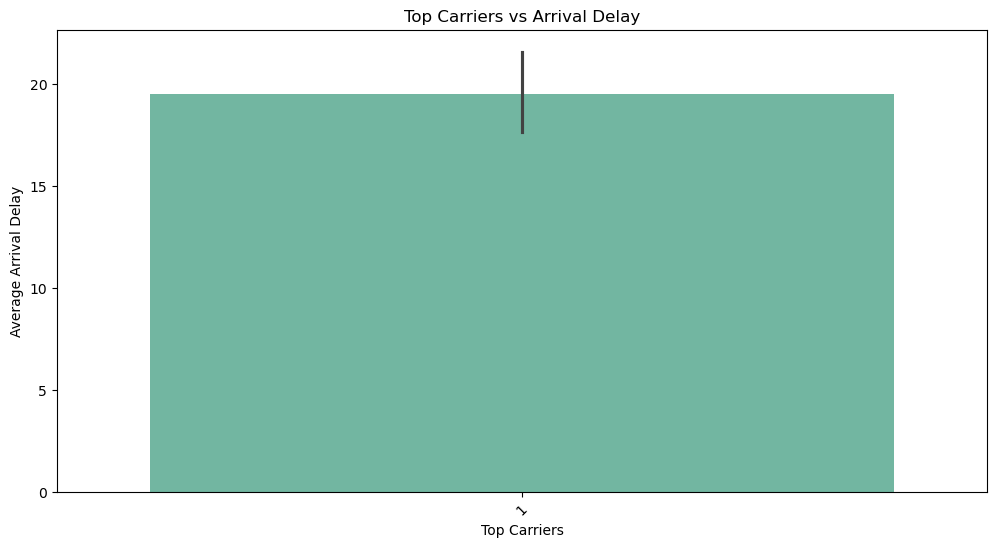

In [29]:
plt.figure(figsize=(12,6))

sns.barplot(
    data=df,
    x='Top_Carriers',
    y='Arrival_Delay',
    palette='Set2'
)

plt.title('Top Carriers vs Arrival Delay')
plt.xlabel('Top Carriers')
plt.ylabel('Average Arrival Delay')

plt.xticks(rotation=45)

plt.show()

The graph compares different airlines with average arrival delays.

Some carriers show higher average delays, indicating differences in airline operational efficiency and flight management performance.

# Multivariate Analysis:-

# Origin Airport, Cancellation and Carriers

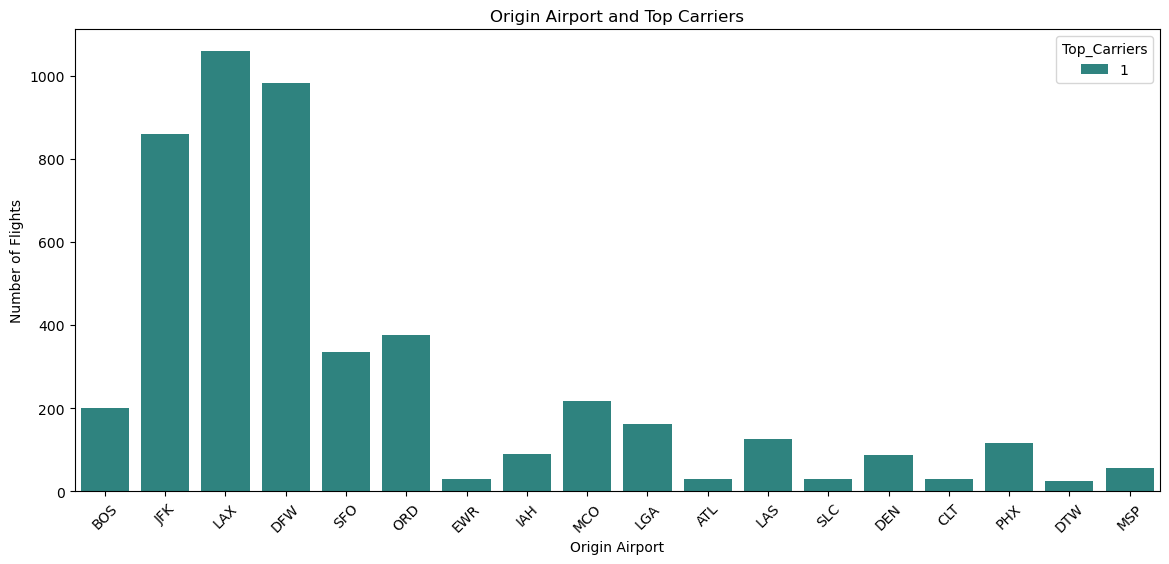

In [30]:
plt.figure(figsize=(14,6))

sns.countplot(
    data=df,
    x='Origin_Airport',
    hue='Top_Carriers',
    palette='viridis'
)

plt.title('Origin Airport and Top Carriers')
plt.xlabel('Origin Airport')
plt.ylabel('Number of Flights')

plt.xticks(rotation=45)

plt.show()

# Insight:

The graph represents the distribution of airlines across different origin airports.

Some airports are dominated by specific carriers, showing that certain airlines operate more frequently from particular airports.

# Correlation Heatmap

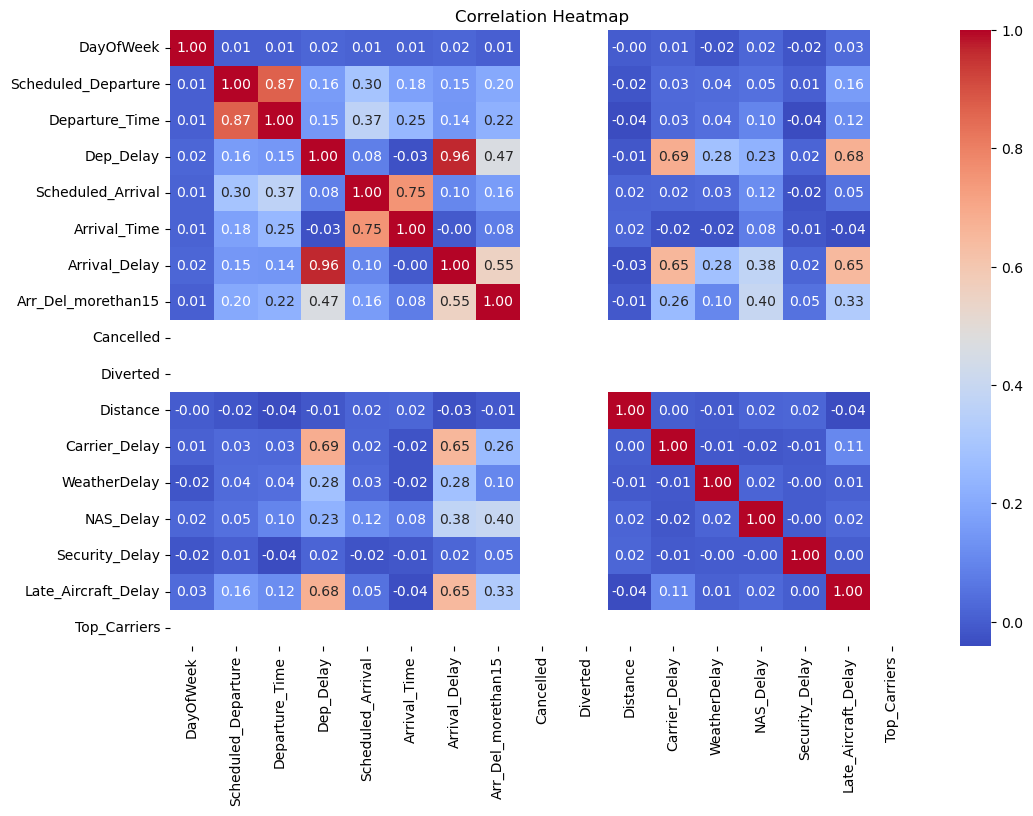

In [31]:
plt.figure(figsize=(12,8))

corr = df.select_dtypes(include='number').corr()

sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Correlation Heatmap')

plt.show()

# Insight:

The heatmap shows relationships among numerical variables in the dataset.

Strong positive correlations can be observed between departure delay and arrival delay,

indicating that delayed departures often lead to delayed arrivals. Weak correlations among some variables suggest limited direct relationships.

# Departure Delay by Day Of Week and Top Carriers

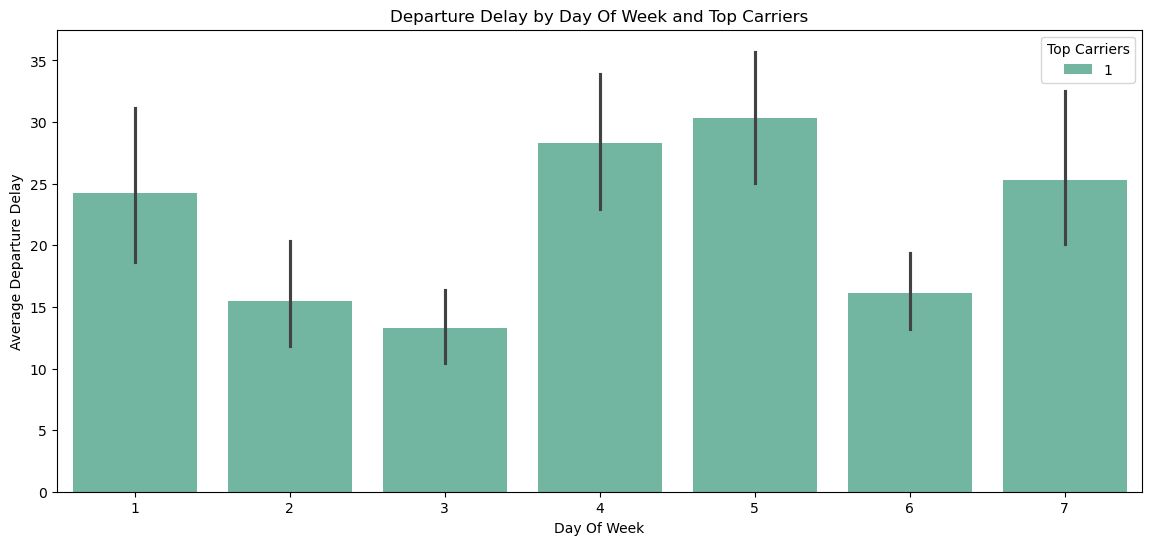

In [32]:
plt.figure(figsize=(14,6))

sns.barplot(
    data=df,
    x='DayOfWeek',
    y='Dep_Delay',
    hue='Top_Carriers',
    palette='Set2'
)

plt.title('Departure Delay by Day Of Week and Top Carriers')
plt.xlabel('Day Of Week')
plt.ylabel('Average Departure Delay')

plt.legend(title='Top Carriers')

plt.show()

# Insight:

The graph shows how departure delays vary across different days of the week for various airlines.

Some carriers experience higher delays on specific days, indicating that airline performance and traffic conditions differ throughout the week.

#Final Insights

Flight Delay Patterns

Departure delays and arrival delays are strongly related.

Flights departing late are more likely to arrive late.

Delay patterns vary across different days of the week.

# Airport Performance

Some origin airports handle a significantly larger number of flights.

Certain airports show higher cancellation and delay frequencies, which may indicate traffic congestion or operational challenges.

# Airline Performance
Airline performance differs across carriers.

Some carriers maintain lower average delays, while others experience comparatively higher delays and cancellations.

# Impact of Weather and Operational Factors
Weather-related delays contribute significantly to overall flight disruptions.

Carrier delays, NAS delays, and late aircraft delays also affect flight schedules.

# Conclusion of Flight Delay Analysis

This Exploratory Data Analysis (EDA) project provided valuable insights into flight operations, delays, cancellations, and airline performance.

The analysis revealed that flight delays are influenced by multiple operational factors such as departure timing, carrier efficiency,

airport traffic, and weather conditions. Airports with higher traffic volumes experienced more operational disruptions,

while some airlines demonstrated better on-time performance than others.